# Descripción de proyecto

Trabajas como analista de datos para la empresa de telecomunicaciones Megaline, la cual ofrece a sus clientes dos planes de prepago: Surf y Ultimate. El departamento comercial necesita identificar cuál de estos planes genera mayores ingresos, con el fin de optimizar la asignación del presupuesto de publicidad.

Para apoyar esta decisión, se realizará un análisis preliminar de las tarifas utilizando una muestra de clientes. El conjunto de datos incluye información de 500 usuarios de Megaline, como su ubicación, el plan que utilizan y sus patrones de consumo durante el año 2018, incluyendo la cantidad de llamadas realizadas, mensajes de texto enviados y uso de datos móviles.

Además de estimar los ingresos generados por cada plan, el análisis también se enfocará en comprender el comportamiento de los clientes, identificando patrones de uso y diferencias en el consumo entre los usuarios de cada tarifa.

El objetivo principal de este análisis es evaluar cómo se comportan los clientes según el plan contratado y determinar cuál de los planes de prepago genera mayores ingresos en promedio. Esta diferencia en ingresos será evaluada posteriormente mediante pruebas estadísticas.

# Descripción de las tarifas
Nota: Megaline redondea los segundos a minutos y los megabytes a gigabytes. Para las llamadas, cada llamada individual se redondea: incluso si la llamada duró solo un segundo, se contará como un minuto. Para el tráfico web, las sesiones web individuales no se redondean. En vez de esto, el total del mes se redondea hacia arriba. Si alguien usa 1025 megabytes este mes, se le cobrarán 2 gigabytes.

A continuación puedes ver una descripción de las tarifas:
    
Surf

Pago mensual: $20.00\
500 minutos al mes, 50 SMS y 15 GB de datos\
Si se exceden los límites del paquete:\
1 minuto: 3 centavos\
1 SMS: 3 centavos\
1 GB de datos: $10.\
Ultimate

Pago mensual: $70.\
3000 minutos al mes, 1000 SMS y 30 GB de datos.\
Si se exceden los límites del paquete:\
1 minuto: 1 centavo\
1 SMS: 1 centavo\
1 GB de datos: $7.00

### Análisis general de los datos
1- Obtener todas las bases de datos y librerías necesarias

2- Visualizar el tipo de datos que se van a manejar

3- Visualizar posibles duplicados 

4- Corregir datos

5- Enriquecer los datos

In [1]:
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import math
# -----------------------------------------------------------------------#
meg_calls = pd.read_csv('datasets/megaline_calls.csv')
meg_internet = pd.read_csv('datasets/megaline_internet.csv')
meg_msm = pd.read_csv('datasets/megaline_messages.csv')
meg_plans = pd.read_csv('datasets/megaline_plans.csv')
meg_users = pd.read_csv('datasets/megaline_users.csv')

In [2]:
meg_calls.info()
meg_calls.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


,id,user_id,call_date,duration
53791,1193_252,1193,2018-10-24,0.00
67678,1243_66,1243,2018-12-26,4.80
32543,1122_381,1122,2018-10-14,0.00
94480,1336_347,1336,2018-10-20,14.02
121774,1428_269,1428,2018-12-16,9.97


In [3]:
meg_internet.info()
meg_internet.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


,id,user_id,session_date,mb_used
97162,1458_139,1458,2018-09-24,402.95
54022,1245_55,1245,2018-09-08,758.23
83896,1391_109,1391,2018-10-28,432.64
18810,1084_72,1084,2018-11-25,347.86
82780,1386_95,1386,2018-12-26,0.00


In [4]:
meg_msm.info()
meg_msm.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


,id,user_id,message_date
31267,1195_134,1195,2018-12-17
28380,1174_170,1174,2018-07-05
51089,1331_264,1331,2018-11-12
55317,1347_354,1347,2018-09-19
51440,1335_29,1335,2018-07-03


In [5]:
meg_plans.info()
meg_plans.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [6]:
meg_users.info()
meg_users.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
129,1129,Marin,Bolton,70,"Baton Rouge, LA MSA",2018-11-10,surf,2018-12-27
176,1176,Terrance,Shaffer,75,"New York-Newark-Jersey City, NY-NJ-PA MSA",2018-10-03,surf,NaN
393,1393,Wilfredo,Rosa,44,"Knoxville, TN MSA",2018-10-29,surf,NaN
337,1337,Lucius,Arnold,31,"Riverside-San Bernardino-Ontario, CA MSA",2018-03-11,surf,NaN
173,1173,Tristan,Cain,27,"Oxnard-Thousand Oaks-Ventura, CA MSA",2018-09-28,surf,NaN


Se puede ver que en todos los datasets el tipo de dato para las fechas es incorrecto.

En "churn date" hay información vacía, sin embargo en este caso se puede conservar este estado ya que indica que no se han cancelado las suscripciones.

En la base de datos meg_plans, los nombres de las columnas son demasiado largas, esto se puede reducir.

Múltiples bases de datos presentan valores en 0, marcando que en determinado día no se usó internet o no se mandaron mensajes. Tomando en cuenta que el objetivo es estudiar el comportamiento de clientes orientado a ajustar precios, esto no nos ayuda por lo que hay que eliminarlo.
Además, en base a las condiciones de la suscripción se debe de redondear hacia arriba el internet consumido, así que esto se debe de corregir.

### Corrección de datos

Problemas encontrados:

meg_calls:

Tipo de dato en columna call_date incorrecta\
Llamadas con duración de 0.0 se debe de eliminar

meg_internet:

Tipo de dato en columna session_date incorrecta\
Internet con uso de 0.0 se debe de eliminar\
Redondear los números decimales hacia arriba

meg_msm:

Tipo de dato en columna message_date incorrecta

meg_users:

Tipo de dato en columna reg_date y churn_date incorrecta\
Nombres de algunas columnas se pueden reducir como plan_name a plan

In [7]:
# Cambio al tipo fecha de las columnas marcadas#

meg_users[['churn_date', 'reg_date']] = meg_users[[
    'churn_date', 'reg_date']].apply(pd.to_datetime)
meg_calls['call_date'] = pd.to_datetime(meg_calls['call_date'])
meg_internet['session_date'] = pd.to_datetime(meg_internet['session_date'])
meg_msm['message_date'] = pd.to_datetime(meg_msm['message_date'])

# Eliminar los datos con valor de 0#

meg_calls.drop(meg_calls[meg_calls['duration'] == 0.0].index, inplace=True)
meg_internet.drop(
    meg_internet[meg_internet['mb_used'] == 0.0].index, inplace=True)

# Eliminar los datos duplicados#

meg_internet.drop_duplicates(inplace=True)
meg_calls.drop_duplicates(inplace=True)
meg_users.drop_duplicates(inplace=True)
meg_msm.drop_duplicates(inplace=True)

# Renombrar algunas columnas#

meg_plans = meg_plans.rename(columns={'plan_name': 'plan'})

In [8]:
meg_calls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110901 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         110901 non-null  object        
 1   user_id    110901 non-null  int64         
 2   call_date  110901 non-null  datetime64[ns]
 3   duration   110901 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB


In [9]:
meg_internet.info()

<class 'pandas.core.frame.DataFrame'>
Index: 91078 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            91078 non-null  object        
 1   user_id       91078 non-null  int64         
 2   session_date  91078 non-null  datetime64[ns]
 3   mb_used       91078 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.5+ MB


In [10]:
meg_msm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB


In [11]:
meg_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


### Enriquecimiento de datos

Se extrajo el componente mensual de las variables de fecha en los distintos datasets para estandarizar la dimensión temporal del análisis y permitir la agregación consistente de la actividad de los usuarios por ciclo de facturación. Adicionalmente, se convirtió el límite de datos incluidos de megabytes a gigabytes utilizando redondeo hacia arriba (ceil) para reflejar las reglas de facturación del negocio y asegurar la precisión en el cálculo de ingresos y excedentes de consumo.

In [12]:
meg_msm["period"] = meg_msm["message_date"].dt.month
meg_calls["period"] = meg_calls["call_date"].dt.month
meg_users['month_reg'] = meg_users['reg_date'].dt.month
meg_users['month_churn'] = meg_users['churn_date'].dt.month
meg_internet["period"] = meg_internet["session_date"].dt.month
meg_plans['mb_per_month_included'] = np.ceil(
    meg_plans['mb_per_month_included'] / 1024)

# Agregación de información

Esta sección nos va a servir para poder calcular las métricas a nivel de usuario y período mensual, con esto para poder empezar a analizar los comportamientos de los clientes dentro de cada ciclo de facturación y unirlo todo en un dataset

A continuación se obtendrá la información de consumo de cada usuario por cada servicio que ofrece los distintos planes

In [13]:
# Agregar los datos por usuario y por periodo de cada dataset#
llamadas_mes = meg_calls.groupby(['user_id', 'period']).size().reset_index()
min_llamadas = meg_calls.groupby(['user_id', 'period'])[
    'duration'].sum().reset_index()
n_mensajes = meg_msm.groupby(['user_id', 'period']).size().reset_index()
inter_trafic = meg_internet.groupby(['user_id', 'period'])[
    'mb_used'].sum().reset_index()

# Renombre de columnas#

llamadas_mes = llamadas_mes.rename(columns={0: 'calls_n'})
n_mensajes.rename(columns={0: 'n_msm'}, inplace=True)

Después de obtener todos los datos de manera individual los agrupamos todos para poder leer la información de una manera más limpia y organizada.
Además, aquí se redondean dos datos: MB usados y duración de llamadas hacia arriba.

In [14]:
total = pd.merge(llamadas_mes, min_llamadas, on=[
                 'user_id', 'period'], how='outer')
total = pd.merge(total, inter_trafic, on=['user_id', 'period'], how='outer')
total = pd.merge(total, n_mensajes, on=['user_id', 'period'], how='outer')
total = pd.merge(
    total, meg_users[['user_id', 'plan', 'city']], on='user_id', how='outer')
total = total.fillna(0)
total['mb_used'] = np.ceil(total['mb_used'] / 1024)
total['duration'] = np.ceil(total['duration'])
total.info()
total
total.to_excel('datasets/total.xlsx', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   2303 non-null   int64  
 1   period    2303 non-null   float64
 2   calls_n   2303 non-null   float64
 3   duration  2303 non-null   float64
 4   mb_used   2303 non-null   float64
 5   n_msm     2303 non-null   float64
 6   plan      2303 non-null   object 
 7   city      2303 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 144.1+ KB


Con el dataset anterior se hará un nuevo dataset en donde se expondrán dos cosas: los límites que uno puede consumir por período y, al lado, lo que ha consumido extra en ese período. Teniendo como columna final lo que el usuario va a pagar en total, este total se calculará teniendo en cuenta la tarifa mencionada al inicio del proyecto y sumando lo extra por cada plan.

In [15]:
# Calculamos los excedentes
total_extra = total.merge(meg_plans, on='plan')
pares = [
    ('duration', 'minutes_included', 'minutos'),
    ('n_msm', 'messages_included', 'mensajes'),
    ('mb_used', 'mb_per_month_included', 'mb')
]
for usado, limite, prefijo in pares:
    total_extra[f'{prefijo}_dentro_plan'] = total_extra[[
        usado, limite]].min(axis=1)
    total_extra[f'{prefijo}_excedido'] = (
        total_extra[usado] - total_extra[limite]).clip(lower=0)
nuevo_orden = [
    'user_id', 'period', 'plan',
    'messages_included', 'mensajes_dentro_plan', 'mensajes_excedido',
    'mb_per_month_included', 'mb_dentro_plan', 'mb_excedido',
    'minutes_included', 'minutos_dentro_plan', 'minutos_excedido',
    'usd_monthly_pay', 'usd_per_gb', 'usd_per_message', 'usd_per_minute'
]
total_extra = total_extra[nuevo_orden]
total_extra['pago_total'] = (total_extra['usd_monthly_pay'] +
                             (total_extra['mb_excedido'] * total_extra['usd_per_gb']) +
                             (total_extra['mensajes_excedido'] * total_extra['usd_per_message']) +
                             (total_extra['minutos_excedido'] * total_extra['usd_per_minute']))
total_extra.info()
total_extra

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                2303 non-null   int64  
 1   period                 2303 non-null   float64
 2   plan                   2303 non-null   object 
 3   messages_included      2303 non-null   int64  
 4   mensajes_dentro_plan   2303 non-null   float64
 5   mensajes_excedido      2303 non-null   float64
 6   mb_per_month_included  2303 non-null   float64
 7   mb_dentro_plan         2303 non-null   float64
 8   mb_excedido            2303 non-null   float64
 9   minutes_included       2303 non-null   int64  
 10  minutos_dentro_plan    2303 non-null   float64
 11  minutos_excedido       2303 non-null   float64
 12  usd_monthly_pay        2303 non-null   int64  
 13  usd_per_gb             2303 non-null   int64  
 14  usd_per_message        2303 non-null   float64
 15  usd_

,user_id,period,plan,messages_included,mensajes_dentro_plan,mensajes_excedido,mb_per_month_included,mb_dentro_plan,mb_excedido,minutes_included,minutos_dentro_plan,minutos_excedido,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,pago_total
0,1000,12.0,ultimate,1000,11.0,0.0,30.0,2.0,0.0,3000,117.0,0.0,70,7,0.01,0.01,70.00
1,1001,8.0,surf,50,30.0,0.0,15.0,7.0,0.0,500,172.0,0.0,20,10,0.03,0.03,20.00
2,1001,9.0,surf,50,44.0,0.0,15.0,14.0,0.0,500,298.0,0.0,20,10,0.03,0.03,20.00
3,1001,10.0,surf,50,50.0,3.0,15.0,15.0,7.0,500,375.0,0.0,20,10,0.03,0.03,90.09
4,1001,11.0,surf,50,36.0,0.0,15.0,15.0,4.0,500,405.0,0.0,20,10,0.03,0.03,60.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2298,1498,12.0,surf,50,0.0,0.0,15.0,15.0,8.0,500,325.0,0.0,20,10,0.03,0.03,100.00
2299,1499,9.0,surf,50,0.0,0.0,15.0,13.0,0.0,500,331.0,0.0,20,10,0.03,0.03,20.00
2300,1499,10.0,surf,50,0.0,0.0,15.0,15.0,5.0,500,364.0,0.0,20,10,0.03,0.03,70.00
2301,1499,11.0,surf,50,0.0,0.0,15.0,15.0,2.0,500,289.0,0.0,20,10,0.03,0.03,40.00


Ahora se van a calcular los ingresos mensuales por cliente para cuantificar el valor económico generado por cada usuario dentro de un ciclo de facturación. Esta métrica permite comparar la rentabilidad de los distintos planes y evaluar el impacto del comportamiento de uso sobre los ingresos del servicio.

In [16]:
# calculamos los costos
def calcular_ingresos(df):
    # Calcular cargos por excedentes
    costo_minutos = df['minutos_excedido'] * df['usd_per_minute']
    costo_mensajes = df['mensajes_excedido'] * df['usd_per_message']
    costo_datos = df['mb_excedido'] * df['usd_per_gb']
    df['ingreso_mensual'] = df['usd_monthly_pay'] +\
        costo_minutos + costo_mensajes + costo_datos

    return df


df_s = calcular_ingresos(total_extra)
df_s
total = pd.merge(
    total,
    df_s[['user_id', 'period', 'ingreso_mensual']],
    on=['user_id', 'period'],
    how='outer'
)
total.info()
total

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2303 entries, 0 to 2302
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   user_id          2303 non-null   int64  
 1   period           2303 non-null   float64
 2   calls_n          2303 non-null   float64
 3   duration         2303 non-null   float64
 4   mb_used          2303 non-null   float64
 5   n_msm            2303 non-null   float64
 6   plan             2303 non-null   object 
 7   city             2303 non-null   object 
 8   ingreso_mensual  2303 non-null   float64
dtypes: float64(6), int64(1), object(2)
memory usage: 162.1+ KB


,user_id,period,calls_n,duration,mb_used,n_msm,plan,city,ingreso_mensual
0,1000,12.0,16.0,117.0,2.0,11.0,ultimate,"Atlanta-Sandy Springs-Roswell, GA MSA",70.00
1,1001,8.0,22.0,172.0,7.0,30.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
2,1001,9.0,38.0,298.0,14.0,44.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",20.00
3,1001,10.0,47.0,375.0,22.0,53.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",90.09
4,1001,11.0,49.0,405.0,19.0,36.0,surf,"Seattle-Tacoma-Bellevue, WA MSA",60.00
...,...,...,...,...,...,...,...,...,...
2298,1498,12.0,32.0,325.0,23.0,0.0,surf,"New York-Newark-Jersey City, NY-NJ-PA MSA",100.00
2299,1499,9.0,35.0,331.0,13.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",20.00
2300,1499,10.0,41.0,364.0,20.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",70.00
2301,1499,11.0,39.0,289.0,17.0,0.0,surf,"Orlando-Kissimmee-Sanford, FL MSA",40.00


# Estudio del comportamiento de los usuarios

En este apartado se harán varios cálculos a nivel estadístico para llegar a poder determinar la mayor ventaja económica y trazar gráficas para el análisis respectivo.

# Llamadas

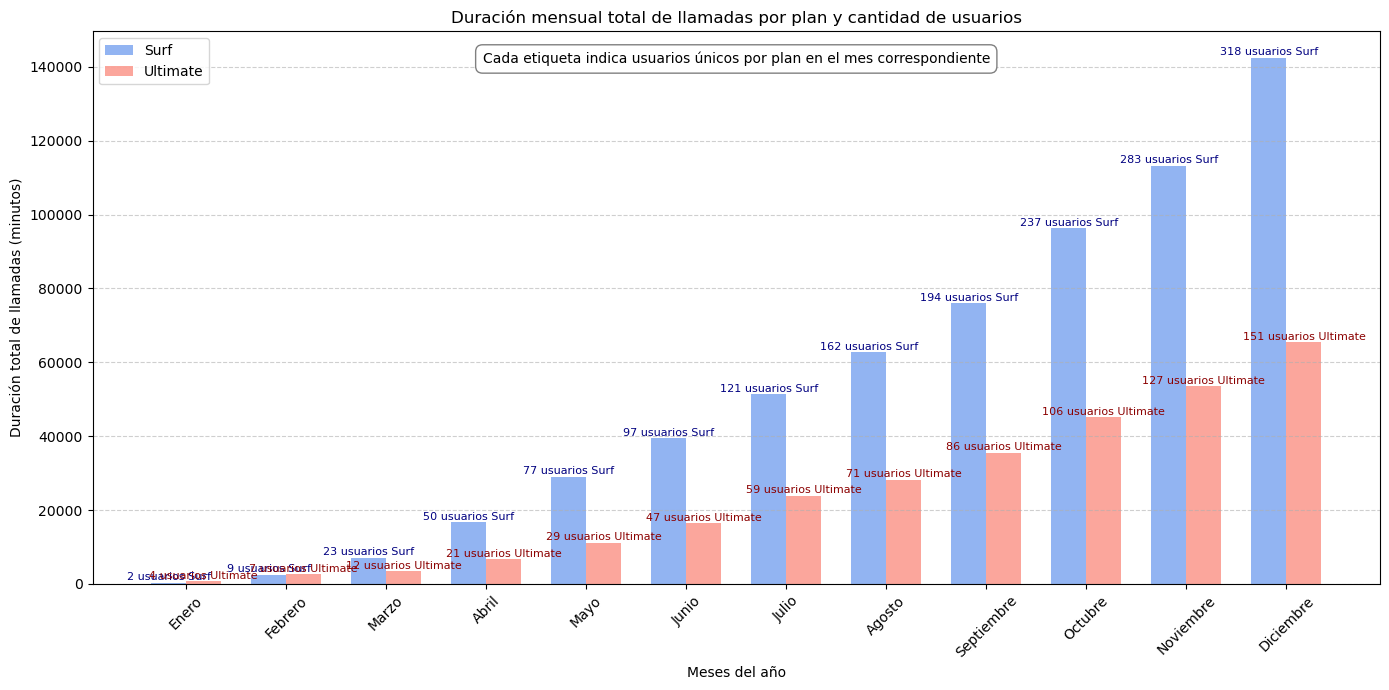

In [17]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.
call_total = total.groupby(['period', 'plan'])[
    ['duration']].sum().reset_index()
usuarios_por_plan_mes = total.groupby(['period', 'plan'])[
    'user_id'].nunique().reset_index()
meses = list(range(1, 13))
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
x = list(range(len(meses)))
ancho = 0.35
x_surf = [i - ancho/2 for i in x]
x_ultimate = [i + ancho/2 for i in x]
surf_call = call_total[call_total['plan'] == 'surf'].set_index(
    'period')['duration'].reindex(meses, fill_value=0)
ultimate_call = call_total[call_total['plan'] == 'ultimate'].set_index(
    'period')['duration'].reindex(meses, fill_value=0)
surf_users = usuarios_por_plan_mes[usuarios_por_plan_mes['plan'] == 'surf'].set_index(
    'period')['user_id'].reindex(meses, fill_value=0)
ultimate_users = usuarios_por_plan_mes[usuarios_por_plan_mes['plan'] == 'ultimate'].set_index(
    'period')['user_id'].reindex(meses, fill_value=0)
plt.figure(figsize=(14, 7))
bars_surf = plt.bar(x_surf, surf_call, ancho, label='Surf',
                    alpha=0.7, color='cornflowerblue')
bars_ultimate = plt.bar(x_ultimate, ultimate_call, ancho,
                        label='Ultimate', alpha=0.7, color='salmon')
for i, (bar_s, bar_u) in enumerate(zip(bars_surf, bars_ultimate)):
    plt.text(bar_s.get_x() + bar_s.get_width()/2, bar_s.get_height() + 100,
             f'{surf_users.iloc[i]} usuarios Surf', ha='center', va='bottom', fontsize=8, color='navy')
    plt.text(bar_u.get_x() + bar_u.get_width()/2, bar_u.get_height() + 100,
             f'{ultimate_users.iloc[i]} usuarios Ultimate', ha='center', va='bottom', fontsize=8, color='darkred')
plt.text(0.5, 0.95,
         'Cada etiqueta indica usuarios únicos por plan en el mes correspondiente',
         ha='center', va='center',
         transform=plt.gca().transAxes,
         fontsize=10,
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.5'))

plt.xlabel('Meses del año')
plt.ylabel('Duración total de llamadas (minutos)')
plt.title('Duración mensual total de llamadas por plan y cantidad de usuarios')
plt.xticks(x, nombres_meses, rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

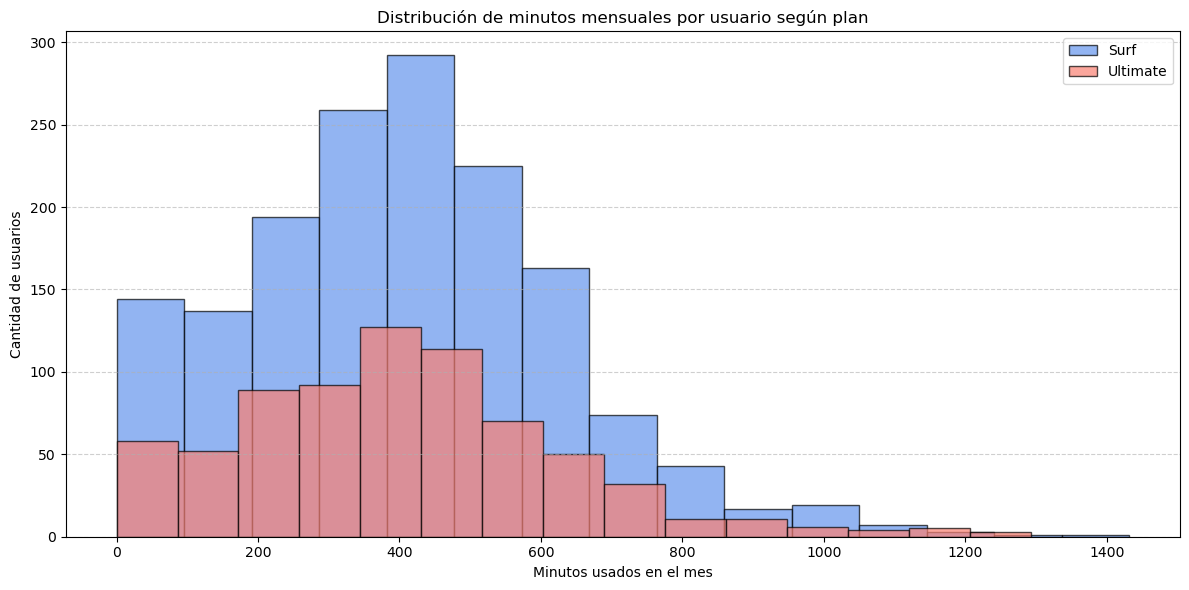

In [18]:

# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
duracion_por_usuario = total.groupby(['user_id', 'period', 'plan'])[
    'duration'].sum().reset_index()
surf_duracion = duracion_por_usuario[duracion_por_usuario['plan']
                                     == 'surf']['duration']
ultimate_duracion = duracion_por_usuario[duracion_por_usuario['plan']
                                         == 'ultimate']['duration']
plt.figure(figsize=(12, 6))
plt.hist(surf_duracion, bins=15, alpha=0.7, label='Surf',
         color='cornflowerblue', edgecolor='black')
plt.hist(ultimate_duracion, bins=15, alpha=0.7,
         label='Ultimate', color='salmon', edgecolor='black')

plt.title('Distribución de minutos mensuales por usuario según plan')
plt.xlabel('Minutos usados en el mes')
plt.ylabel('Cantidad de usuarios')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
# Calcula la media y la varianza de la duración mensual de llamadas.
llamadas = total.groupby(['plan', 'period'])[
    'duration'].sum().unstack(fill_value=0)
promedio_ultimate = llamadas.loc['ultimate'].mean()
var_u = llamadas.loc['ultimate'].var()
llamadas_s = llamadas.loc['surf'].mean()
var_s = llamadas.loc['surf'].var()
print(f'''Promedio de duracion para el plan Ultimate: {promedio_ultimate:.2f}
Promedio de duracion para el plan Surf: {llamadas_s:.2f}
Varianza de duracion para el plan Ultimate: {var_u:.2f}
Varianza de duracion para el plan Surf: {var_s:.2f}
''')

Promedio de duracion para el plan Ultimate: 22525.23
Promedio de duracion para el plan Surf: 49035.08
Varianza de duracion para el plan Ultimate: 472979378.19
Varianza de duracion para el plan Surf: 2185191321.24



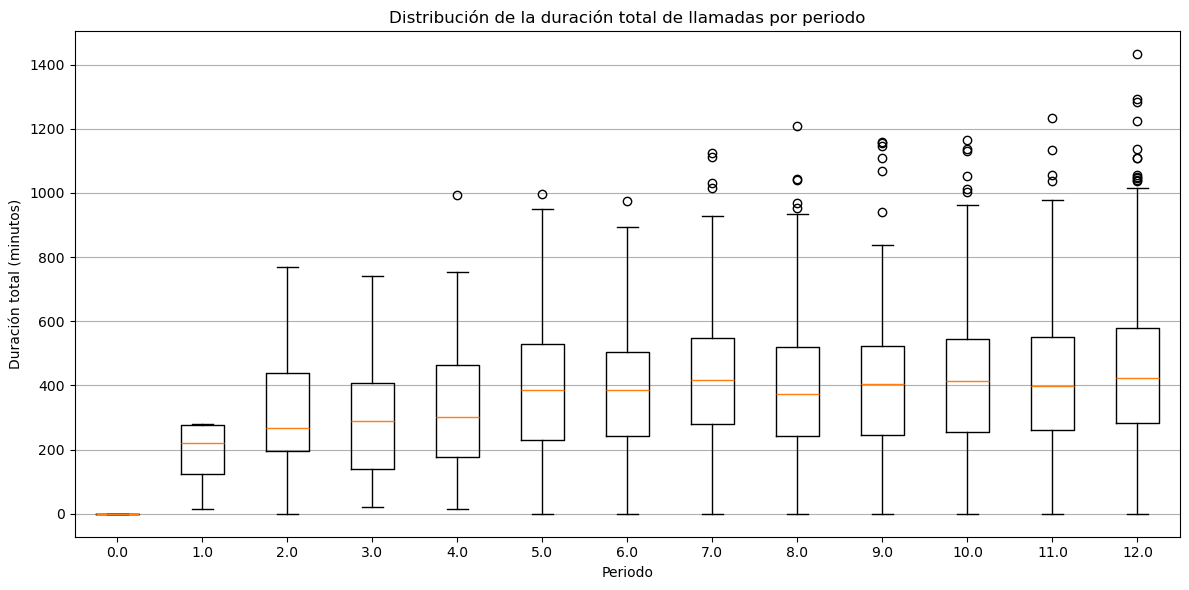

In [20]:
monthly_duration = (
    total
    .groupby(['period', 'user_id'])['duration']
    .sum()
    .reset_index()
)

# Crear datos para el boxplot por periodo
periods = sorted(monthly_duration['period'].unique())

data_by_period = [
    monthly_duration.loc[
        monthly_duration['period'] == p, 'duration'
    ]
    for p in periods
]

plt.figure(figsize=(12, 6))

plt.boxplot(data_by_period)

plt.title('Distribución de la duración total de llamadas por periodo')
plt.xlabel('Periodo')
plt.ylabel('Duración total (minutos)')

plt.xticks(range(1, len(periods) + 1), periods)

plt.grid(axis='y')

plt.tight_layout()
plt.show()

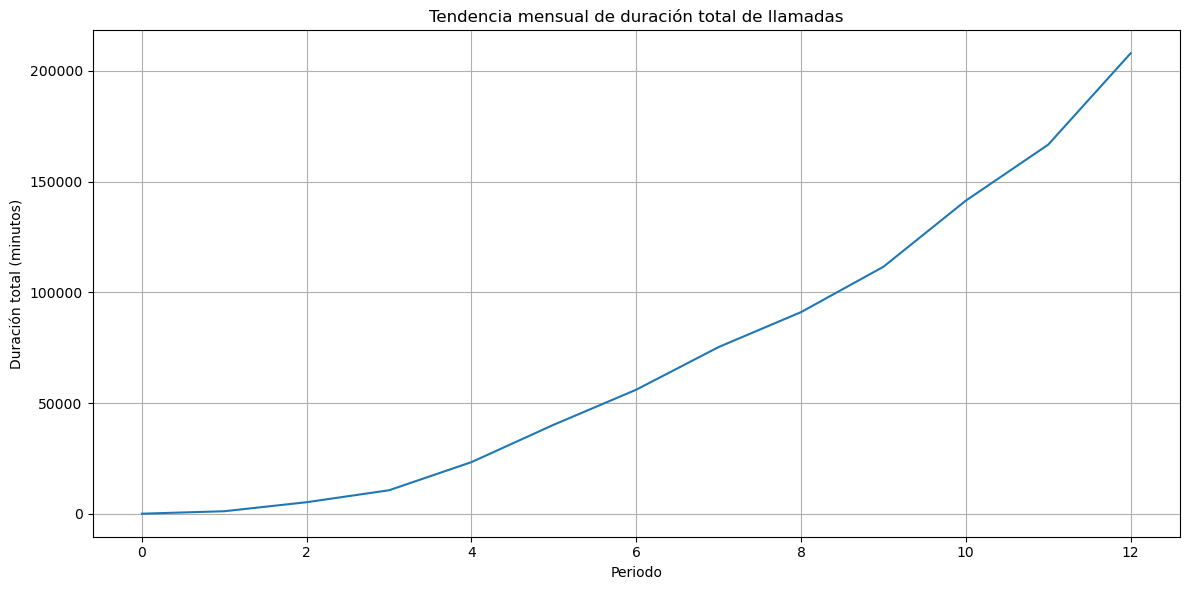

In [21]:
trend = (
    total
    .groupby('period')['duration']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    trend['period'],
    trend['duration']
)

plt.title('Tendencia mensual de duración total de llamadas')
plt.xlabel('Periodo')
plt.ylabel('Duración total (minutos)')

plt.grid(True)

plt.tight_layout()
plt.show()

# Mensajes

In [22]:
# Compara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
msm = total.groupby(['period', 'plan'])['n_msm'].sum().unstack(fill_value=0)
msm.sort_values(by='surf', ascending=False, inplace=True)
msm_u = msm['ultimate'].reindex(range(1, 13), fill_value=0)
msm_s = msm['surf'].reindex(range(1, 13), fill_value=0)

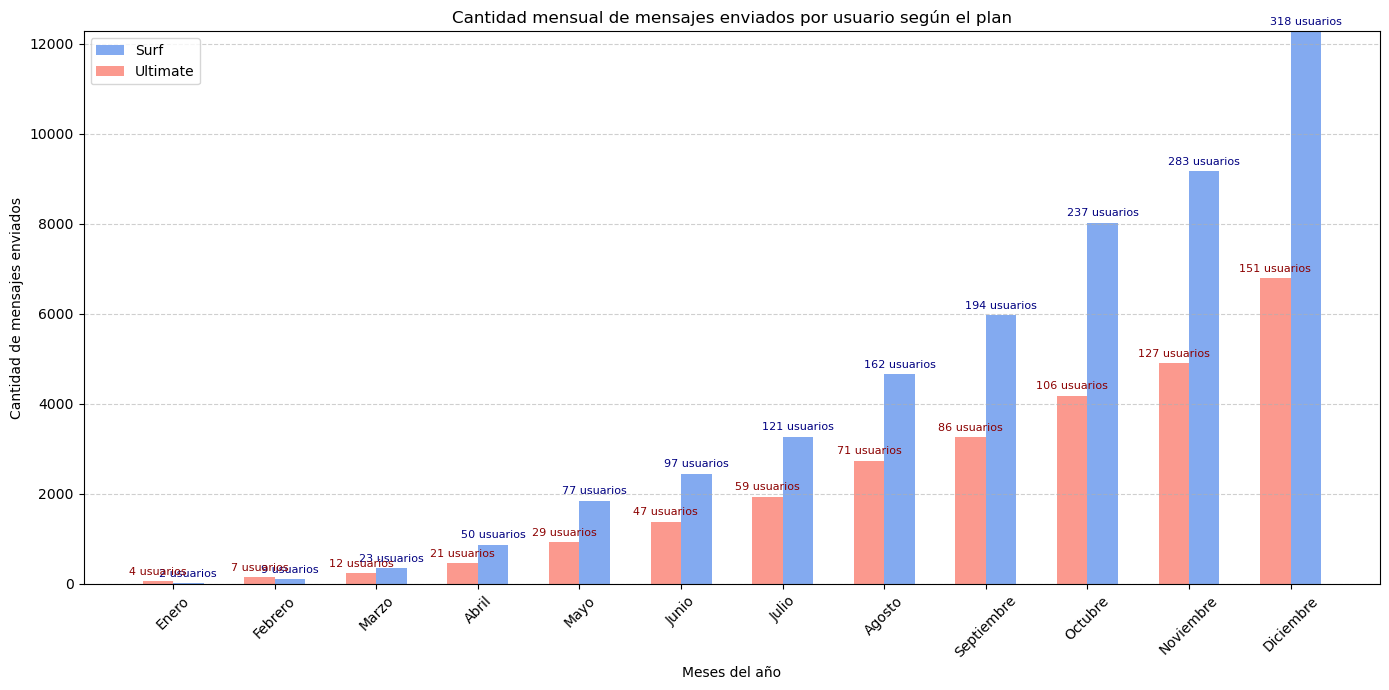

In [23]:
meses = list(range(1, 13))
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
x = list(range(len(meses)))
ancho = 0.30
x_surf = [i + ancho / 2 for i in x]
x_ultimate = [i - ancho / 2 for i in x]
msm_s = msm_s.reindex(meses, fill_value=0)
msm_u = msm_u.reindex(meses, fill_value=0)
max_valor = max(msm_s.max(), msm_u.max())
limite_superior = math.ceil(max_valor)+1
plt.figure(figsize=(14, 7))
bars_surf = plt.bar(x_surf, msm_s, ancho, label='Surf',
                    alpha=0.8, color='cornflowerblue')
bars_ultimate = plt.bar(x_ultimate, msm_u, ancho,
                        label='Ultimate', alpha=0.8, color='salmon')
for i, (bar_s, bar_u) in enumerate(zip(bars_surf, bars_ultimate)):
    altura_s = bar_s.get_height()
    altura_u = bar_u.get_height()
    plt.text(bar_s.get_x() + bar_s.get_width()/2, altura_s + 100,
             f'{surf_users.iloc[i]} usuarios', ha='center', va='bottom', fontsize=8, color='navy')
    plt.text(bar_u.get_x() + bar_u.get_width()/2, altura_u + 100,
             f'{ultimate_users.iloc[i]} usuarios', ha='center', va='bottom', fontsize=8, color='darkred')
plt.title('Cantidad mensual de mensajes enviados por usuario según el plan')
plt.xlabel('Meses del año')
plt.ylabel('Cantidad de mensajes enviados')
plt.xticks(x, nombres_meses, rotation=45)
plt.ylim(0, limite_superior)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Internet

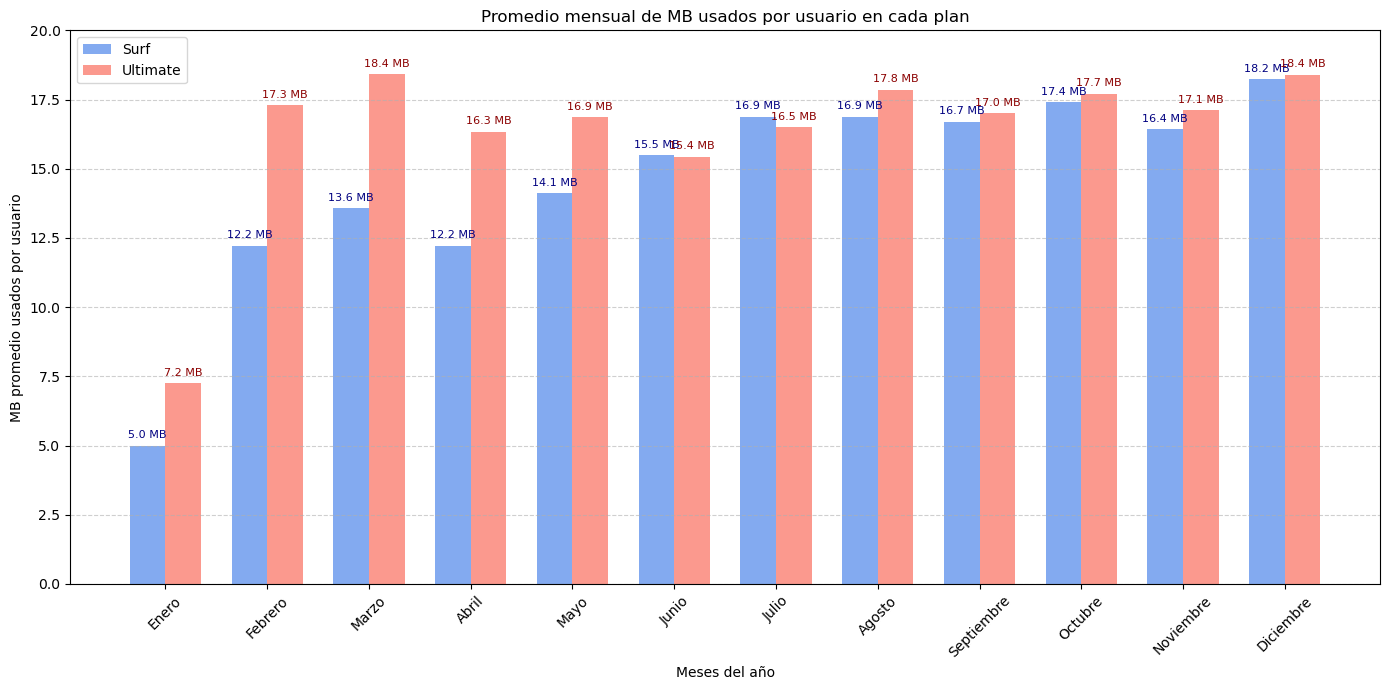

In [24]:
# Promedio de internet usado por los usuarios en los distintos planes

mb_promedio = total.groupby(['period', 'plan'])['mb_used'].mean().reset_index()
meses = list(range(1, 13))
nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
x = list(range(len(meses)))
ancho = 0.35
x_surf = [i - ancho/2 for i in x]
x_ultimate = [i + ancho/2 for i in x]

surf_mb = mb_promedio[mb_promedio['plan'] == 'surf'].set_index(
    'period')['mb_used'].reindex(meses, fill_value=0)
ultimate_mb = mb_promedio[mb_promedio['plan'] == 'ultimate'].set_index(
    'period')['mb_used'].reindex(meses, fill_value=0)

# Calculamos el máximo valor para adaptar el eje Y
max_valor = max(surf_mb.max(), ultimate_mb.max())
limite_superior = math.ceil(max_valor) + 1

plt.figure(figsize=(14, 7))
bars_surf = plt.bar(x_surf, surf_mb, ancho, label='Surf',
                    alpha=0.8, color='cornflowerblue')
bars_ultimate = plt.bar(x_ultimate, ultimate_mb, ancho,
                        label='Ultimate', alpha=0.8, color='salmon')

for bar in bars_surf:
    altura = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, altura + 0.2, f'{altura:.1f} MB',
             ha='center', va='bottom', fontsize=8, color='navy')

for bar in bars_ultimate:
    altura = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, altura + 0.2, f'{altura:.1f} MB',
             ha='center', va='bottom', fontsize=8, color='darkred')

plt.title('Promedio mensual de MB usados por usuario en cada plan')
plt.xlabel('Meses del año')
plt.ylabel('MB promedio usados por usuario')
plt.xticks(x, nombres_meses, rotation=45)
plt.ylim(0, limite_superior)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Ingresos

Recopilando toda la información anterior, podremos empezar a sacar conclusiones

In [25]:
# En que ciudad es donde se registran mas usuarios y en que fecha del año
ingreso = meg_users.groupby(['month_reg', 'plan'])[
    'user_id'].count().reset_index(name='count')
ingreso.sort_values(by='count', ascending=False, inplace=True)
city = meg_users.groupby('city')['user_id'].count().reset_index(name='count')
city.sort_values(by='count', ascending=False, inplace=True)
city

,city,count
43,"New York-Newark-Jersey City, NY-NJ-PA MSA",80
34,"Los Angeles-Long Beach-Anaheim, CA MSA",29
20,"Dallas-Fort Worth-Arlington, TX MSA",21
14,"Chicago-Naperville-Elgin, IL-IN-WI MSA",19
49,"Philadelphia-Camden-Wilmington, PA-NJ-DE-MD MSA",17
...,...,...
66,"Stockton, CA MSA",1
27,"Greensboro-High Point, NC MSA",1
24,"El Paso, TX MSA",1
11,"Cape Coral-Fort Myers, FL MSA",1


In [26]:
# en que plan se registran mas usuarios
trafic1 = total.groupby('user_id')['plan'].unique()
trafic = total.groupby(['period', 'plan'])[
    'user_id'].count().unstack(fill_value=0)
trafic_s = trafic['surf'].sum()
trafic_u = trafic['ultimate'].sum()
print(f'''Cantidad de usuarios que usan el plan Surf: {trafic_s}
Cantidad de usuarios que usan el plan Ultimate: {trafic_u}''')

Cantidad de usuarios que usan el plan Surf: 1579
Cantidad de usuarios que usan el plan Ultimate: 724


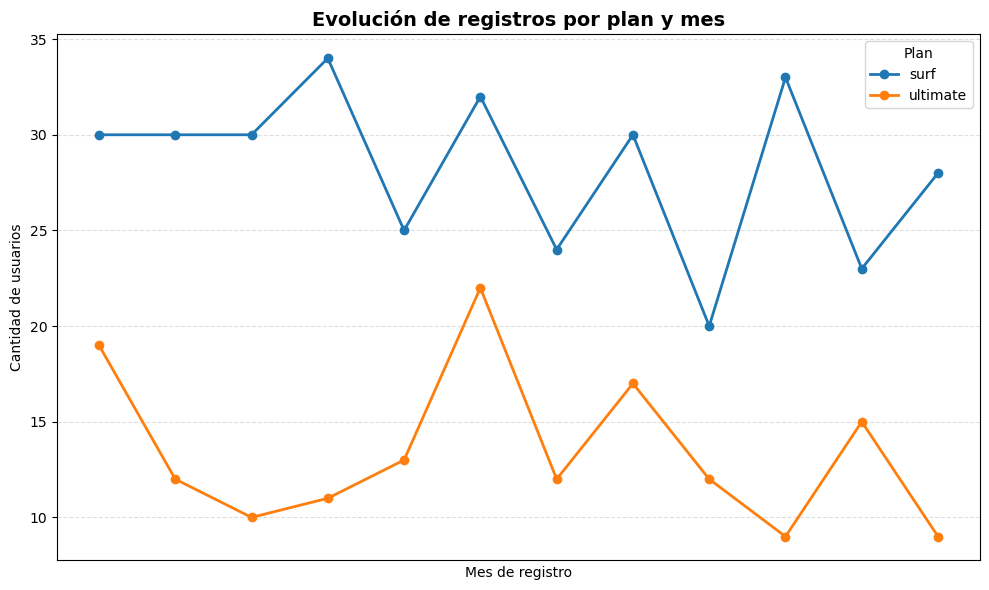

In [27]:
ingreso['month_reg'] = pd.to_datetime(ingreso['month_reg'])
ingreso.sort_values(by='month_reg', inplace=True)

# Crear figura
plt.figure(figsize=(10, 6))

# Graficar líneas por plan
planes = ingreso['plan'].unique()
for plan in planes:
    datos = ingreso[ingreso['plan'] == plan]
    plt.plot(datos['month_reg'], datos['count'],
             label=plan, marker='o', linewidth=2)

# Decoración
plt.title('Evolución de registros por plan y mes', fontsize=14, weight='bold')
plt.xlabel('Mes de registro')
plt.ylabel('Cantidad de usuarios')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Plan')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

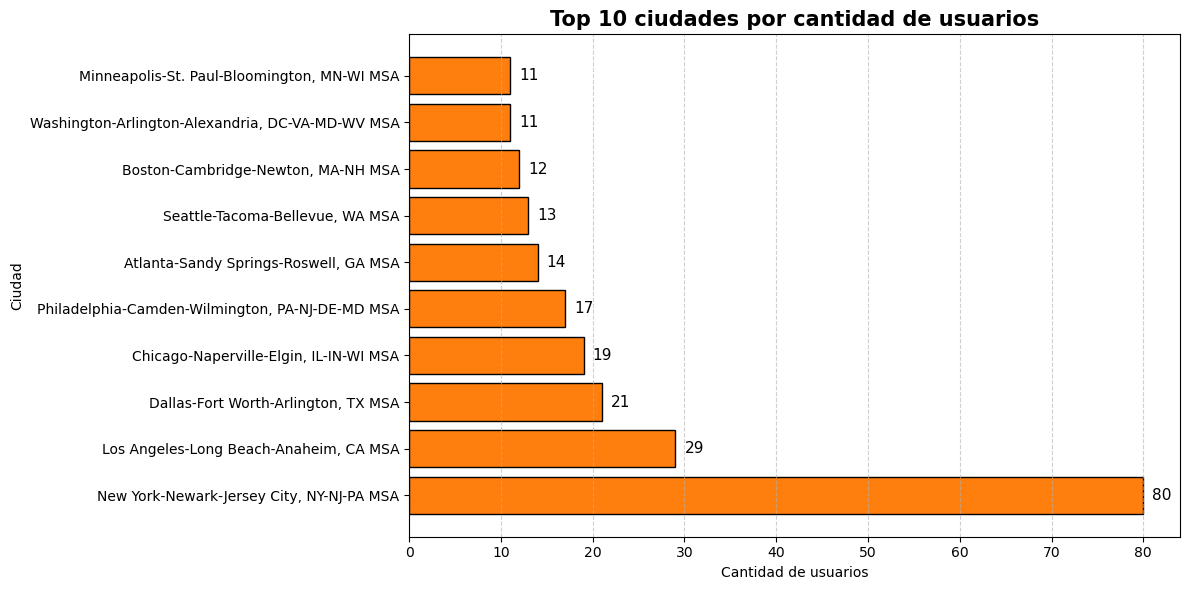

In [28]:
top_city = city.head(10)
plt.figure(figsize=(12, 6))
bars = plt.barh(top_city['city'], top_city['count'],
                color='#ff7f0e', edgecolor='black')
plt.title('Top 10 ciudades por cantidad de usuarios',
          fontsize=15, weight='bold')
plt.xlabel('Cantidad de usuarios')
plt.ylabel('Ciudad')
plt.grid(axis='x', linestyle='--', alpha=0.6)
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1,
             bar.get_y() + bar.get_height()/2,
             str(int(width)),
             va='center', ha='left', fontsize=11, color='black')

plt.tight_layout()
plt.show()

In [29]:
# confirmando que ciudad genera mas ganancias
total_s = total[total['plan'] == 'surf']['ingreso_mensual'].sum()
total_u = total[total['plan'] == 'ultimate']['ingreso_mensual'].sum()
print(f'surf: {total_s}, ultimate: {total_u}')

surf: 95022.04000000001, ultimate: 52346.0


# Pruebas de hipotesis estadisticas

In [30]:
ganancias_u = total[total['plan'] == 'ultimate']['ingreso_mensual']
ganancias_s = total[total['plan'] != 'ultimate']['ingreso_mensual']
alpha = 0.05
t_stat, p_value = st.ttest_ind(ganancias_s, ganancias_u, equal_var=False)
print('''Hipótesis nula: Hay una diferencia entre los ingresos del plan Surf y del plan Ultimate
''')
if p_value < alpha:
    print('Se rechaza la hipótesis nula')
else:
    print('No se rechaza la hipótesis nula')

Hipótesis nula: Hay una diferencia entre los ingresos del plan Surf y del plan Ultimate

Se rechaza la hipótesis nula


In [31]:
# NY_NJ genera más ganancias que el resto de las ciudades:
ganancias_nj = total[total['city'] ==
                     'New York-Newark-Jersey City, NY-NJ-PA MSA']['ingreso_mensual'].sum()
ganancias_ciudad = total.groupby('city')['ingreso_mensual'].sum().reset_index()
result = st.ttest_1samp(ganancias_ciudad['ingreso_mensual'], ganancias_nj)
print('Hipótesis nula: La ciudad de New York genera más ganancias que el resto de las ciudades')
if result.pvalue < alpha:
    print('No se rechaza la hipótesis nula')
else:
    print('Se rechaza la hipótesis nula: se generan más ganancias en otra ciudad')

Hipótesis nula: La ciudad de New York genera más ganancias que el resto de las ciudades
No se rechaza la hipótesis nula


El ingreso promedio de los usuarios de NY-NJ es distinto al de los usuarios de otras regiones

In [32]:
# Prueba las hipótesis
promedio = total_extra.groupby(
    'user_id')['ingreso_mensual'].mean().reset_index()
promedio = pd.merge(
    promedio, meg_users[['user_id', 'city']], on='user_id', how='outer')
media_ciudades = promedio.groupby(
    'city')['ingreso_mensual'].mean().reset_index()
ny_nj = media_ciudades[media_ciudades['city'] ==
                       'New York-Newark-Jersey City, NY-NJ-PA MSA']
media_ciudades = media_ciudades[media_ciudades['city'] !=
                                'New York-Newark-Jersey City, NY-NJ-PA MSA']
print('Hipótesis nula: Los ingresos promedio del área de NY-NJ es diferente al de los usuarios de otras regiones')
alpha = 0.05
ny_nj_valor = ny_nj['ingreso_mensual'].values[0]
results = st.ttest_1samp(media_ciudades['ingreso_mensual'], ny_nj_valor,)

if (results.pvalue/2 < alpha):
    print('Se rechaza la hipótesis nula')
else:
    print('No se rechaza la hipótesis nula')

Hipótesis nula: Los ingresos promedio del área de NY-NJ es diferente al de los usuarios de otras regiones
No se rechaza la hipótesis nula


Con esto confirmamos que los ingresos de esta región son superiores

¿El plan Surf genera más ganancias que el plan Ultimate?

In [33]:
ganancias_s = total[total['plan'] == 'ultimate']['ingreso_mensual']
ganancias_u = total[total['plan'] != 'ultimate']['ingreso_mensual']
t_stat, p_value_1 = st.ttest_ind(ganancias_s, ganancias_u, equal_var=False)
alpha = 0.05
ganancias_s
if t_stat > 0:
    pruebat = p_value_1/2
else:
    pruebat = 1-(p_value_1/2)
print('''Hipótesis nula: Surf genera más ganancias que Ultimate''')
print(f'Valor p: {pruebat}')
if pruebat < alpha:
    print('No se rechaza la hipótesis nula: Surf genera más ganancias')
else:
    print('Se rechaza la hipótesis nula: Ultimate genera más ganancias que Surf')

Hipótesis nula: Surf genera más ganancias que Ultimate
Valor p: 6.756531989073508e-17
No se rechaza la hipótesis nula: Surf genera más ganancias


Con esta prueba de hipótesis nos damos cuenta de que los clientes pagan menos al exceder los límites del plan Surf que al pagar el plan Ultimate, que ofrece más límite

# Conclusiones

## Conclusión general
A lo largo del análisis se puede ver que el servicio de telefonía ha aumentado su nivel de usuarios con respecto al inicio del año y muy pocos usuarios se han ido, hay una buena retención de audiencia.
La mayor cantidad de audiencia está en Nueva York, por lo que ahí es posible que se encuentre su sede principal. Sin embargo, el hecho de que haya muy poca gente en otras ciudades es algo preocupante, eso quiere decir que se le tiene que destinar más presupuesto a la publicidad, porque la cantidad de ciudades que abarca es algo grande para la cantidad de usuarios que tienen.
También se puede ver que el fuerte de la empresa es en el plan Surf, puesto que genera casi el doble de ganancias que Ultimate. Aquí se le puede bajar de precio a Ultimate, y esto atraería más gente y por ende mejores ganancias.